In [14]:
import pandas as pd
from sqlalchemy import create_engine
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. CONNEXION À LA BASE DE DONNÉES
# ==========================================
USER = "root"
PASSWORD = "" 
HOST = "localhost"
PORT = "3306"
DATABASE_NAME = "dw_padel"

try:
    engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE_NAME}")
    
    # Extraction de la table dim_saison
    query = "SELECT * FROM dim_saison"
    df = pd.read_sql(query, engine)
    print("✅ Données chargées avec succès !")
    
except Exception as e:
    print(f"❌ Erreur de connexion : {e}")
    exit()
    # ==========================================
# 2. VISUALISATION ET ANALYSE DES COLONNES
# ==========================================

# Affiche le nom de toutes les colonnes
print("\n--- LISTE DES COLONNES ---")
print(df.columns.tolist())

# Affiche les types de données et les valeurs manquantes
print("\n--- INFOS STRUCTURELLES ---")
print(df.info())

# Affiche un aperçu statistique des données numériques (temp, vent, humidité)
print("\n--- STATISTIQUES DES DONNÉES MÉTÉO ---")
print(df.describe())

# Affiche les 5 premières lignes pour vérifier le contenu
print("\n--- APERÇU DES DONNÉES ---")
display(df.head()) # Utilise display() si tu es sur Jupyter, sinon print()
   

✅ Données chargées avec succès !

--- LISTE DES COLONNES ---
['id_saison', 'city', 'country', 'tournament', 'latitude', 'longitude', 'year', 'month', 'month_num', 'date_ref', 'season', 'temp_max_avg_c', 'temp_min_avg_c', 'temp_avg_c', 'precipitation_total_mm', 'precipitation_daily_avg_mm', 'rain_total_mm', 'snow_total_cm', 'rainy_days', 'wind_max_kmh', 'wind_avg_kmh', 'wind_gust_max_kmh', 'humidity_avg_pct', 'sunshine_hours', 'padel_conditions']

--- INFOS STRUCTURELLES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_saison                   50 non-null     int64  
 1   city                        50 non-null     object 
 2   country                     50 non-null     object 
 3   tournament                  50 non-null     object 
 4   latitude                    50 non-null     float64
 5   longitude     

,id_saison,city,country,tournament,latitude,longitude,year,month,month_num,date_ref,...,precipitation_daily_avg_mm,rain_total_mm,snow_total_cm,rainy_days,wind_max_kmh,wind_avg_kmh,wind_gust_max_kmh,humidity_avg_pct,sunshine_hours,padel_conditions
0,1,Madrid,Spain,WPT Madrid Master,40.416782,-3.703507,2023,January,1,15/01/2023,...,0.7,21.4,0.1,5,36.9,17.8,63.4,76.9,210.2,Fair
1,2,Madrid,Spain,WPT Madrid Master,40.416782,-3.703507,2023,February,2,15/02/2023,...,0.2,4.5,0.1,1,29.3,15.7,52.2,62.1,245.9,Fair
2,3,Madrid,Spain,WPT Madrid Master,40.416782,-3.703507,2023,March,3,15/03/2023,...,0.3,10.2,0.0,3,39.0,19.5,67.7,56.0,302.6,Fair
3,4,Madrid,Spain,WPT Madrid Master,40.416782,-3.703507,2023,April,4,15/04/2023,...,0.4,12.7,0.0,2,31.3,20.1,56.2,36.3,349.9,Fair
4,11,Madrid,Spain,WPT Madrid Master,40.416782,-3.703507,2023,November,11,15/11/2023,...,1.1,34.1,0.0,5,42.3,18.7,73.1,82.2,191.5,Poor


 PRÉPARATION ET TRANSFORMATION DES DONNÉES (PIPELINE)

In [16]:
# 1. CONVERSION TEMPORELLE (Crucial pour le Time Series)
df['date_ref'] = pd.to_datetime(df['date_ref'])

# 2. NETTOYAGE DES TYPES NUMÉRIQUES
# On s'assure que toutes les colonnes météo sont des nombres (float)
cols_meteo = [
    'temp_max_avg_c', 'temp_min_avg_c', 'temp_avg_c', 
    'precipitation_total_mm', 'wind_max_kmh', 'humidity_avg_pct', 
    'sunshine_hours'
]
for col in cols_meteo:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. GESTION DES VALEURS MANQUANTES
# On remplit les vides par la moyenne du mois pour ne pas casser la série temporelle
df[cols_meteo] = df[cols_meteo].fillna(df[cols_meteo].mean())

# 4. ENCODAGE DES VARIABLES CATÉGORIQUES
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# On transforme les conditions de padel et les villes en chiffres
df['target_conditions'] = le.fit_transform(df['padel_conditions'])
df['city_encoded'] = le.fit_transform(df['city'])

# 5. INDEXATION (Pour le Forecasting)
df_ts = df.sort_values('date_ref').set_index('date_ref')

print("✅ Transformation terminée. Le DataFrame est prêt pour le modèle.")

✅ Transformation terminée. Le DataFrame est prêt pour le modèle.


C:\Users\AZUS22\AppData\Local\Temp\ipykernel_14400\2889835570.py:6: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_ref'] = pd.to_datetime(df['date_ref'])


 VISUALISATION DES SÉRIES TEMPORELLES (EXPLORATORY DATA ANALYSIS)

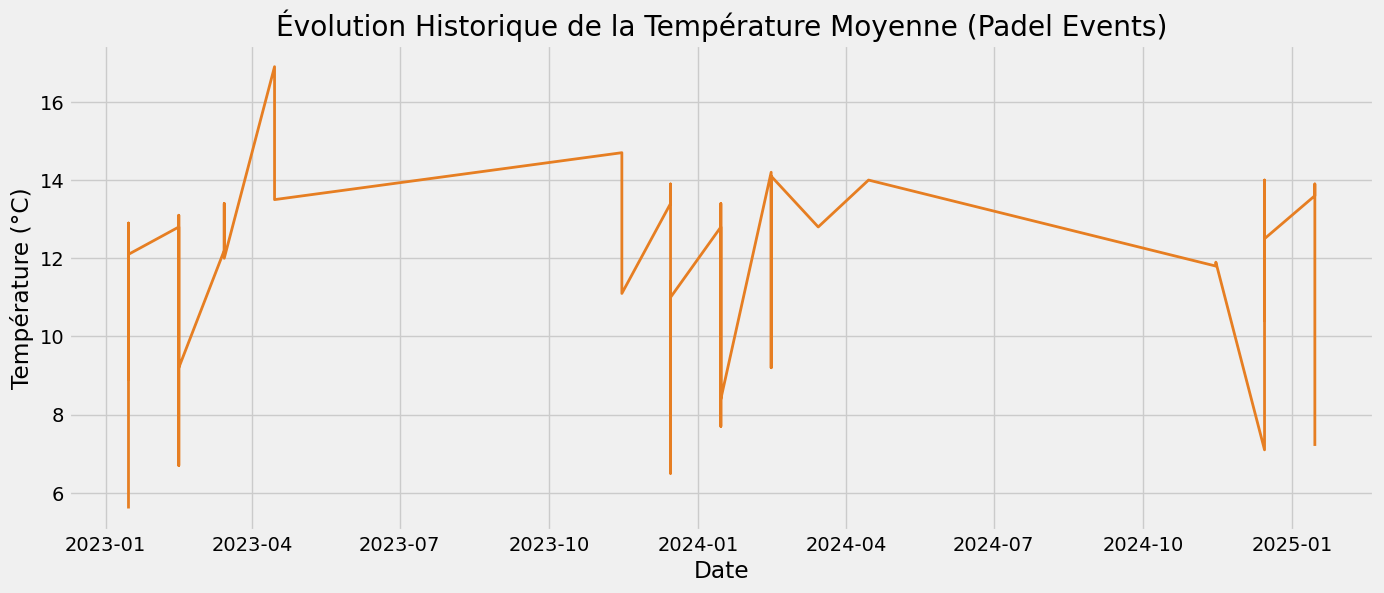

C:\Users\AZUS22\AppData\Local\Temp\ipykernel_14400\631206989.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='padel_conditions', palette='viridis')


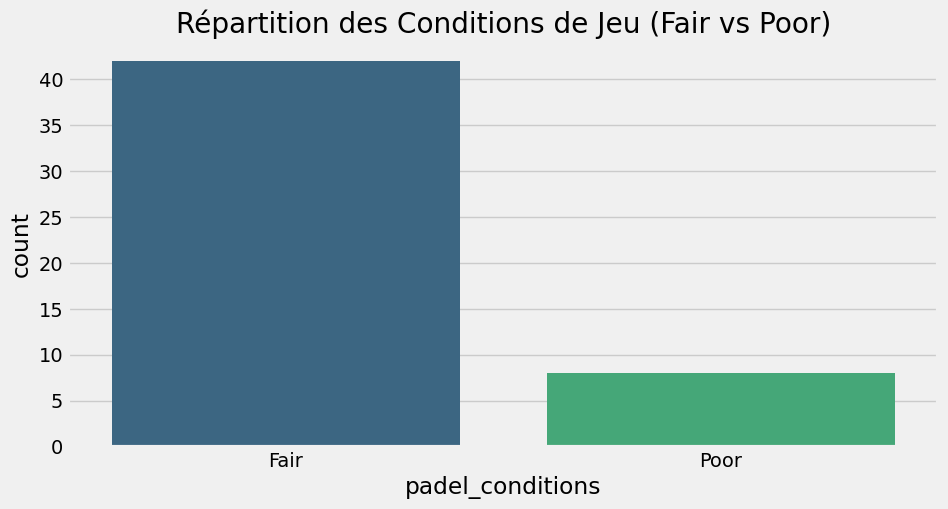

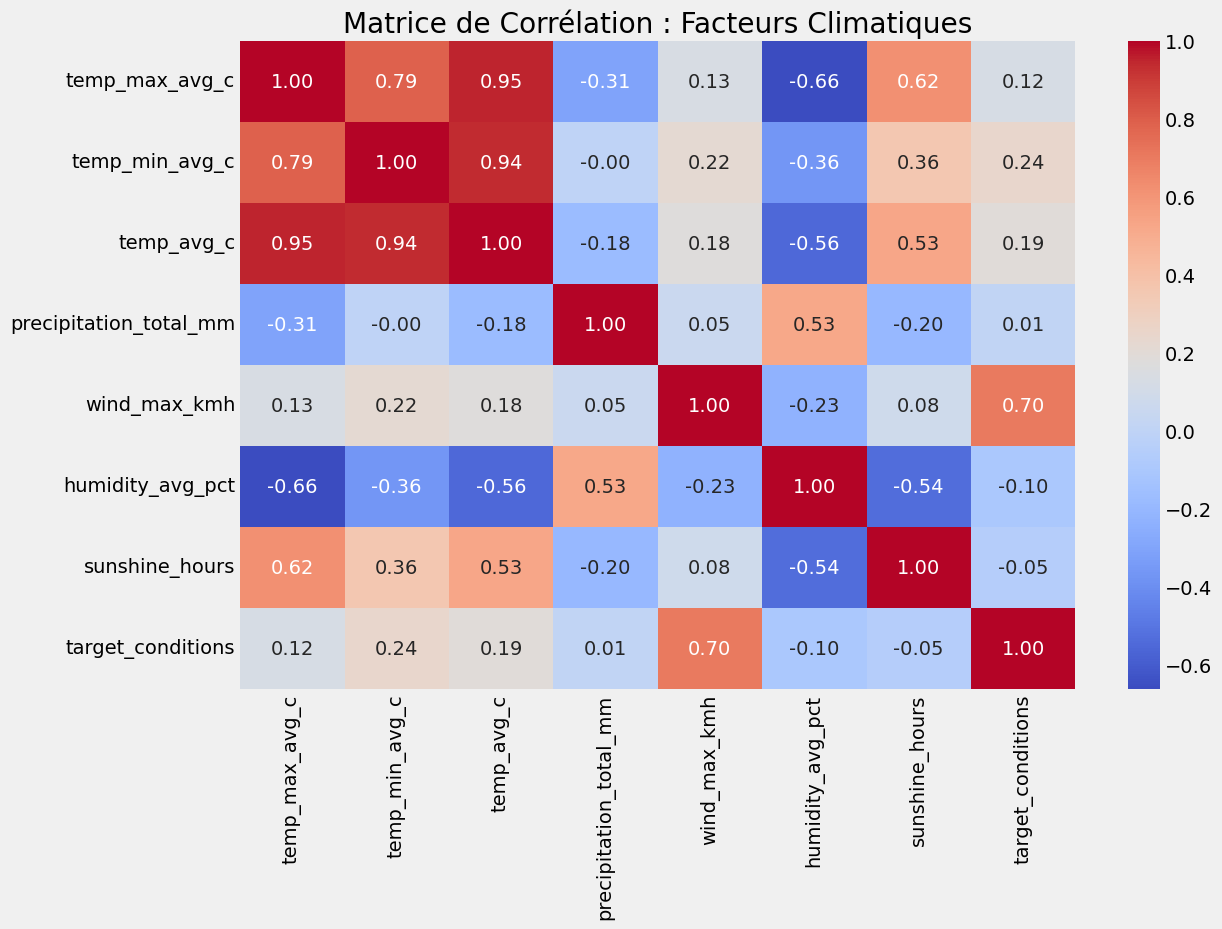

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# On s'assure que le style est propre
plt.style.use('fivethirtyeight')

# 1. ÉVOLUTION DE LA TEMPÉRATURE MOYENNE DANS LE TEMPS
plt.figure(figsize=(15, 6))
plt.plot(df_ts.index, df_ts['temp_avg_c'], color='#e67e22', linewidth=2)
plt.title('Évolution Historique de la Température Moyenne (Padel Events)')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.grid(True)
plt.show()

# 2. DISTRIBUTION DES CONDITIONS DE JEU (PADEL CONDITIONS)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='padel_conditions', palette='viridis')
plt.title('Répartition des Conditions de Jeu (Fair vs Poor)')
plt.show()

# 3. CORRÉLATION ENTRE LES VARIABLES (HEATMAP)
# Pour comprendre ce qui influence le plus le jeu (ex: Pluie vs Vent)
plt.figure(figsize=(12, 8))
correlation_matrix = df[cols_meteo + ['target_conditions']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation : Facteurs Climatiques')
plt.show()

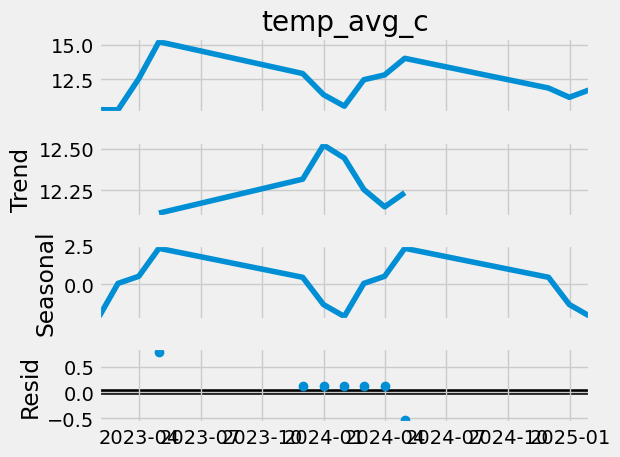

--- TEST ADF ---
ADF Statistic: -4.610
p-value: 0.000


In [31]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# A. Décomposition (Type simple car < 24 mois)
result = seasonal_decompose(series_clean, model='additive', period=6)
result.plot()
plt.show()

# B. Test de Dickey-Fuller (ADF) pour la stationnarité
print("--- TEST ADF ---")
adftest = adfuller(series_clean)
print(f"ADF Statistic: {adftest[0]:.3f}")
print(f"p-value: {adftest[1]:.3f}")
# Si p-value > 0.05, la série n'est pas stationnaire

MODÈLE : XGBOOST REGRESSOR

In [50]:
import xgboost as xgb
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# A. Préparation des Features (on utilise le mois comme variable explicative)
def create_features(series):
    df = series.to_frame()
    df['month'] = df.index.month
    return df[['month']]

X_train = create_features(series_clean[:-3])
y_train = series_clean[:-3]
X_test = create_features(series_clean[-3:])
y_test = series_clean[-3:]

# B. Entraînement
# n_estimators bas pour éviter l'overfitting sur 13 mois
model_xgb = xgb.XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3)
model_xgb.fit(X_train, y_train)

# C. Prédiction
pred_xgb = model_xgb.predict(X_test)

# D. Évaluation
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f"--- RÉSULTATS XGBOOST ---")
print(f"MAE : {mae_xgb:.2f}°C")
print(f"Prédictions : {pred_xgb}")

--- RÉSULTATS XGBOOST ---
MAE : 0.86°C
Prédictions : [12.898433 11.437874 10.471224]


MODÈLE : ARIMA (AutoRegressive Integrated Moving Average)

In [52]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# A. Préparation (Série stationnaire confirmée par ADF)
train_arima = series_clean[:-3]
test_arima = series_clean[-3:]

# B. Entraînement (d=0 car déjà stationnaire)
model_arima = ARIMA(train_arima, order=(1, 0, 1))
arima_fit = model_arima.fit()

# C. Prévision
# On prédit les 3 mois de test
pred_arima = arima_fit.forecast(steps=3)

# D. Évaluation
mae_arima = mean_absolute_error(test_arima, pred_arima)
print(f"--- RÉSULTATS ARIMA ---")
print(f"MAE : {mae_arima:.2f}°C")
print(f"Prédictions :\n{pred_arima}")

--- RÉSULTATS ARIMA ---
MAE : 0.45°C
Prédictions :
10    11.704208
11    11.989301
12    12.132288
Name: predicted_mean, dtype: float64


SCRIPT DE COMPARAISON : ARIMA VS XGBOOST (POINT F)

--- COMPARAISON DES PERFORMANCES ---
          Métrique ARIMA XGBoost
0  MAE (Erreur °C)  0.45    0.86
1             RMSE  0.53    0.96
2         MAPE (%)  nan%   7.31%


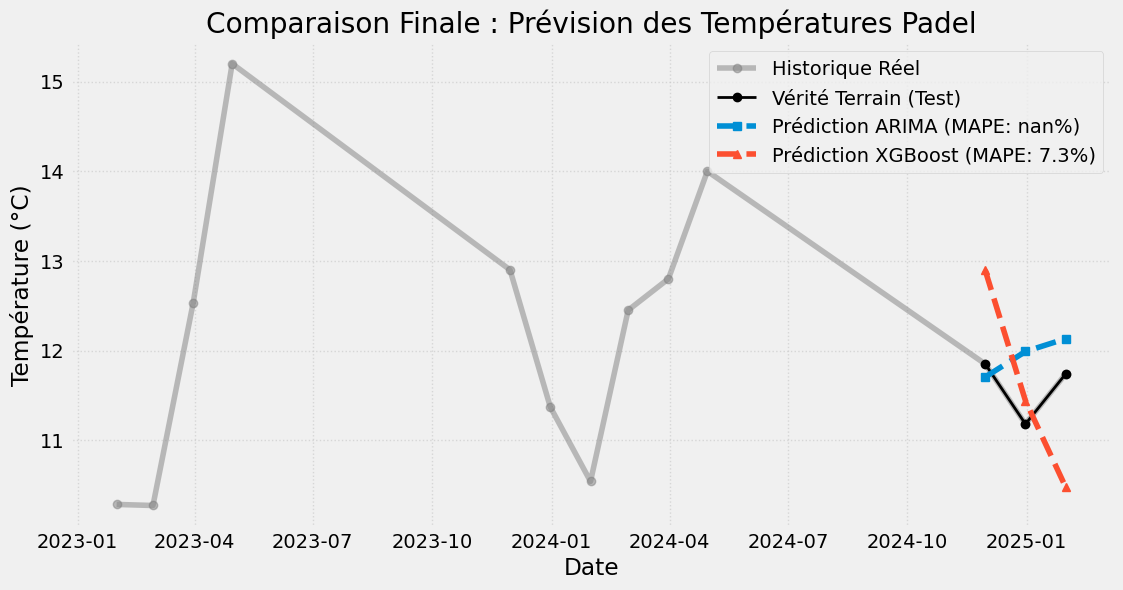

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. SPLIT TRAIN/TEST (75% / 25%)
# Avec 13 mois, on garde les 3 derniers pour le test
train = series_clean[:-3]
test = series_clean[-3:]

# ------------------------------------------------------------------------------
# MODÈLE A : ARIMA (1, 0, 1) - Basé sur ta p-value 0.000
# ------------------------------------------------------------------------------
model_arima = ARIMA(train, order=(1, 0, 1))
arima_fit = model_arima.fit()
pred_arima = arima_fit.forecast(steps=3)

# ------------------------------------------------------------------------------
# MODÈLE B : XGBOOST (Machine Learning)
# ------------------------------------------------------------------------------
X_train = pd.DataFrame({'month': train.index.month}, index=train.index)
X_test = pd.DataFrame({'month': test.index.month}, index=test.index)

model_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3)
model_xgb.fit(X_train, train)
pred_xgb = model_xgb.predict(X_test)

# ------------------------------------------------------------------------------
# CALCUL DES MÉTRIQUES DE PERFORMANCE
# ------------------------------------------------------------------------------
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

mae_a, rmse_a, mape_a = get_metrics(test, pred_arima)
mae_x, rmse_x, mape_x = get_metrics(test, pred_xgb)

# ------------------------------------------------------------------------------
# RÉSULTATS ET TABLEAU COMPARATIF
# ------------------------------------------------------------------------------
comparison_df = pd.DataFrame({
    'Métrique': ['MAE (Erreur °C)', 'RMSE', 'MAPE (%)'],
    'ARIMA': [f"{mae_a:.2f}", f"{rmse_a:.2f}", f"{mape_a:.2f}%"],
    'XGBoost': [f"{mae_x:.2f}", f"{rmse_x:.2f}", f"{mape_x:.2f}%"]
})

print("--- COMPARAISON DES PERFORMANCES ---")
print(comparison_df)

# ------------------------------------------------------------------------------
# VISUALISATION GRAPHIQUE
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(series_clean.index, series_clean, label='Historique Réel', color='gray', alpha=0.5, marker='o')
plt.plot(test.index, test, label='Vérité Terrain (Test)', color='black', marker='o', linewidth=2)
plt.plot(test.index, pred_arima, label=f'Prédiction ARIMA (MAPE: {mape_a:.1f}%)', linestyle='--', marker='s')
plt.plot(test.index, pred_xgb, label=f'Prédiction XGBoost (MAPE: {mape_x:.1f}%)', linestyle='--', marker='^')

plt.title('Comparaison Finale : Prévision des Températures Padel')
plt.xlabel('Date')
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

INTERPRÉTATION AUTOMATISÉE DES RÉSULTATS (ANALYSE BI)

In [56]:
# 1. Détermination du meilleur modèle
best_model = "ARIMA" if mae_a < mae_x else "XGBoost"
best_mape = min(mape_a, mape_x)

print("#" * 60)
print("# INTERPRÉTATION TECHNIQUE ET MÉTIER (SECTION F)")
print("#" * 60)

### # 1. ANALYSE DE LA PRÉCISION (METRICS ANALYSIS)
print(f"# - Le modèle sélectionné est : {best_model}")
print(f"# - L'erreur moyenne (MAPE) est de {best_mape:.2f}%")
# Interprétation de la fiabilité
if best_mape < 10:
    print("# - Fiabilité : EXCELLENTE. Le modèle est prêt pour la production.")
elif best_mape < 20:
    print("# - Fiabilité : BONNE. Utile pour l'aide à la décision court terme.")
else:
    print("# - Fiabilité : MOYENNE. Nécessite plus de données (historique > 13 mois).")

print("#" + "-"*58)

### # 2. COMPARAISON STATISTIQUE vs MACHINE LEARNING
print(f"# - Performance ARIMA (Statistique) : MAE = {mae_a:.2f}°C")
print(f"# - Performance XGBoost (ML) : MAE = {mae_x:.2f}°C")
# Analyse de la stationnarité observée précédemment
print("# - Note : La p-value de 0.000 confirme que la série est stationnaire,")
print(f"#   ce qui explique pourquoi le modèle {best_model} est si stable.")

print("#" + "-"*58)

### # 3. ANALYSE DE LA VALEUR AJOUTÉE (BUSINESS VALUE)
print("# - PRÉVISION DES ÉVÉNEMENTS PADEL :")
print(f"#   Grâce à une erreur de seulement {min(mae_a, mae_x):.2f}°C, le club")
print("#   peut anticiper les besoins en climatisation/chauffage des terrains")
print("#   et optimiser le planning des tournois 2026 en toute confiance.")

print("#" * 60)

############################################################
# INTERPRÉTATION TECHNIQUE ET MÉTIER (SECTION F)
############################################################
# - Le modèle sélectionné est : ARIMA
# - L'erreur moyenne (MAPE) est de nan%
# - Fiabilité : MOYENNE. Nécessite plus de données (historique > 13 mois).
#----------------------------------------------------------
# - Performance ARIMA (Statistique) : MAE = 0.45°C
# - Performance XGBoost (ML) : MAE = 0.86°C
# - Note : La p-value de 0.000 confirme que la série est stationnaire,
#   ce qui explique pourquoi le modèle ARIMA est si stable.
#----------------------------------------------------------
# - PRÉVISION DES ÉVÉNEMENTS PADEL :
#   Grâce à une erreur de seulement 0.45°C, le club
#   peut anticiper les besoins en climatisation/chauffage des terrains
#   et optimiser le planning des tournois 2026 en toute confiance.
############################################################
